# Last-Mile Delivery Audit - DataCo Global

**Track 1 (Analyst) - Predictive Audit of Delivery Volatility.**

DataCo Global is a multi-market supply chain operator (Africa, Europe, LATAM, Pacific Asia, USCA) tracking 65,752 orders across 23 regions and 4 shipping modes between Jan 2015 and Jan 2018. Net margins are shrinking despite revenue growth - the question is whether the delivery process is statistically out of control or just noisy.

**Anchor finding (preview):** the operator has a **scheduling calibration problem**, not a fleet capacity problem. Standard Class (60% of volume) is well-calibrated (4-day SLA, 4-day actual, 62% on-time). Premium tiers are systematically over-promised: First Class promises 1 day, delivers 2 days, runs 95% late. Same Day promises 0 days, delivers 0.5 day, runs 46% late. The audit pinpoints this with statistical significance and a 90-day SARIMA forecast for capacity planning.

**This notebook produces:**
1. OEE breakdown by Shipping Mode (the brief's complex-join requirement)
2. 90-day SARIMA forecast of daily order volume
3. P-chart (statistical process control) on weekly late-delivery rate
4. Per-region significance testing (p-values for each of 23 regions vs grand mean)
5. Tableau-ready extracts for the executive dashboard

**Methodology notes:**
- 'OEE of the delivery fleet' is computed at the **Shipping Mode level** since the dataset is a marketplace dataset without per-vehicle data. This is the closest honest analogue.
- The brief mentions 'monthly seasonality and weekly trends'. In this dataset, neither is statistically present (DoW range = 169.9 to 172.0, monthly range = 168.2 to 174.1, both well within one standard deviation). We document this finding rather than pretending patterns exist - which is itself a valuable audit finding.

## Setup - auto-resolving paths

Run this cell first.

In [10]:


from pathlib import Path

def find_project_root():
    p = Path.cwd().resolve()
    for parent in [p] + list(p.parents):
        if parent.name == "last_mile_audit":
            return parent
        if all((parent / d).exists() for d in ["data","outputs","figures","sql"]):
            return parent
    return Path.cwd()

PROJECT_ROOT = find_project_root()
DATA_DIR    = PROJECT_ROOT / "../dataset"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = PROJECT_ROOT / "figures"
SQL_DIR     = PROJECT_ROOT / "sql"
DB_PATH     = DATA_DIR / "dataco.db"

for d in [OUTPUTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Database     : {DB_PATH} ({'exists' if DB_PATH.exists() else 'MISSING - run sql/load_data.py first'})")

assert DB_PATH.exists(), f"Run `python3 sql/load_data.py` first to build the database"


Project root : /Users/dhruv/Downloads/BA Assignments and projects/Projects BA/Module 03/Track 01/LastMile
Database     : /Users/dhruv/Downloads/BA Assignments and projects/Projects BA/Module 03/Track 01/LastMile/../dataset/dataco.db (exists)


## Part 1 - Connect to the 3NF database and run the OEE join

The brief requires a **3NF normalized database with complex joins to compute OEE**. We've built that schema (see `sql/schema.sql`) and populated it from the source CSV (see `sql/load_data.py`). Database file: `data/dataco.db`.

In [11]:
import sqlite3
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

conn = sqlite3.connect(DB_PATH)

# Show row counts (3NF integrity check)
print("=== 3NF Schema - row counts ===")
for tbl in ["markets","regions","shipping_modes","departments","categories",
             "products","customers","routes","orders","order_items"]:
    n = conn.execute(f"SELECT COUNT(*) FROM {tbl}").fetchone()[0]
    print(f"  {tbl:<20} {n:>10,}")


=== 3NF Schema - row counts ===
  markets                       5
  regions                      23
  shipping_modes                4
  departments                  11
  categories                   51
  products                    118
  customers                20,652
  routes                   11,899
  orders                        0
  order_items                   0


### 1.1 - The brief's complex-join: OEE of the delivery fleet

OEE = Availability x Performance x Quality
- **Availability** = orders completed / orders total (i.e. not cancelled)
- **Performance** = scheduled_days / actual_days, capped at 1.0
- **Quality** = orders on-time / orders total

We use Shipping Mode as the proxy for vehicle class - the dataset has 4 modes that play the same operational role as fleet tiers in a real logistics op.

In [12]:
oee = pd.read_sql("SELECT * FROM vw_oee_by_mode", conn)
print("=== Fleet OEE by Shipping Mode ===")
print(oee.to_string(index=False))

print(f"\n--- Interpretation ---")
print(f"Standard Class (60% of volume) achieves OEE of {oee[oee['mode_name']=='Standard Class']['oee'].iloc[0]:.1%} - the operational baseline.")
print(f"First Class collapses to OEE of {oee[oee['mode_name']=='First Class']['oee'].iloc[0]:.1%} - 1-day SLA promised, 2 days delivered, 95% late.")
print(f"The headline finding: premium tiers are systematically over-promised, not under-resourced.")

oee.to_csv(OUTPUTS_DIR / "oee_by_mode.csv", index=False)


=== Fleet OEE by Shipping Mode ===
     mode_name  sla_scheduled_days  orders_total  orders_completed  orders_on_time  availability  performance  quality    oee
Standard Class                 4.0         39324             37632           24329        0.9570       0.8935   0.6187 0.5290
      Same Day                 0.0          3571              3407            1923        0.9541       0.5164   0.5385 0.2653
  Second Class                 2.0         12778             12256            2975        0.9591       0.5800   0.2328 0.1295
   First Class                 1.0         10079              9602             477        0.9527       0.5000   0.0473 0.0225

--- Interpretation ---
Standard Class (60% of volume) achieves OEE of 52.9% - the operational baseline.
First Class collapses to OEE of 2.2% - 1-day SLA promised, 2 days delivered, 95% late.
The headline finding: premium tiers are systematically over-promised, not under-resourced.


### 1.2 - The 5-way complex join: OEE per Market x Region x Mode

This is the kind of multi-table aggregation the brief is asking for - it joins **orders -> routes -> regions -> markets -> shipping_modes** and computes the operational metrics by every meaningful slice.

In [13]:
five_way = pd.read_sql('''
SELECT m.market_name,
       r.region_name,
       sm.mode_name,
       COUNT(*) AS n,
       ROUND(AVG(o.days_shipping_real), 2)  AS avg_real_days,
       ROUND(AVG(o.days_shipping_sched), 2) AS avg_sched_days,
       ROUND(AVG(CASE WHEN o.late_delivery_risk=0 THEN 1.0 ELSE 0.0 END), 4) AS quality,
       ROUND(SUM(o.order_profit), 0) AS total_profit
FROM orders o
JOIN routes ro       ON o.route_id    = ro.route_id
JOIN regions r       ON ro.region_id  = r.region_id
JOIN markets m       ON r.market_id   = m.market_id
JOIN shipping_modes sm ON o.mode_id   = sm.mode_id
GROUP BY 1, 2, 3
HAVING n > 100
ORDER BY m.market_name, r.region_name, quality DESC
''', conn)

print(f"5-way join result: {len(five_way)} (Market, Region, Mode) combinations with n > 100")
print("\nWorst-performing combinations (lowest on-time rate):")
print(five_way.nsmallest(10, "quality").to_string(index=False))

five_way.to_csv(OUTPUTS_DIR / "five_way_join_oee.csv", index=False)


5-way join result: 72 (Market, Region, Mode) combinations with n > 100

Worst-performing combinations (lowest on-time rate):
 market_name     region_name   mode_name    n  avg_real_days  avg_sched_days  quality  total_profit
      Africa    North Africa First Class  155            2.0             1.0   0.0323        3472.0
      Europe Southern Europe First Class  525            2.0             1.0   0.0343       11267.0
Pacific Asia      South Asia First Class  543            2.0             1.0   0.0368       12733.0
Pacific Asia       West Asia First Class  329            2.0             1.0   0.0395        4606.0
      Africa     West Africa First Class  145            2.0             1.0   0.0414        1973.0
      Europe Northern Europe First Class  551            2.0             1.0   0.0417       13048.0
        USCA     East of USA First Class  357            2.0             1.0   0.0420        6498.0
        USCA      US Center  First Class  328            2.0             1.

### 1.3 - Late-rate by region (full table for the dashboard)

In [14]:
late_region = pd.read_sql("SELECT * FROM vw_late_rate_by_region", conn)
print(f"All 23 regions:")
print(late_region.to_string(index=False))
late_region.to_csv(OUTPUTS_DIR / "late_rate_by_region.csv", index=False)


All 23 regions:
 market_name     region_name  n_orders  n_late  late_rate  avg_real_days  avg_sched_days
      Africa  Central Africa       556     320     0.5755           3.55            2.91
      Africa     East Africa       613     348     0.5677           3.50            2.91
        USCA  South of  USA       1345     753     0.5599           3.50            2.90
Pacific Asia       West Asia      2022    1132     0.5598           3.50            2.92
      Europe  Eastern Europe      1292     723     0.5596           3.52            2.93
Pacific Asia      South Asia      3335    1865     0.5592           3.50            2.90
      Europe  Western Europe     10010    5585     0.5579           3.51            2.92
Pacific Asia  Southeast Asia      4356    2421     0.5558           3.53            2.95
Pacific Asia    Central Asia       184     102     0.5543           3.52            2.88
        USCA      US Center       1935    1071     0.5535           3.47            2.90
     

## Part 2 - Time Series Forecasting (Task 2)

**Methodology decision documented up front.**

The brief asks for SARIMA with monthly seasonality and weekly trends. The actual data:
- DoW averages range 169.9 to 172.0 (well within one std of the daily mean)
- Month-of-year averages range 168.2 to 174.1 (same)
- The series is essentially **white noise around 171 orders/day** during the stable period
- Each market is active in a rotating window (5-month chunks) - aggregating across all markets gives a fully contiguous 1,127-day series with no gaps

We fit SARIMA on the all-markets aggregate. The model will detect that the data is near-stationary and produce a tight forecast band - which itself is useful to a CFO planning capacity. Honest output beats fabricated seasonality.

In [15]:
# Pull daily volume from the database
daily = pd.read_sql("SELECT order_day, n_orders FROM vw_daily_volume ORDER BY order_day", conn,
                     parse_dates=["order_day"])
daily = daily.set_index("order_day")
print(f"Daily series: {len(daily)} days from {daily.index.min().date()} to {daily.index.max().date()}")
print(f"Mean: {daily['n_orders'].mean():.1f}, Std: {daily['n_orders'].std():.1f}")
print(f"Days with zero: {(daily['n_orders']==0).sum()}")

# Force daily frequency and fill missing
daily = daily.asfreq("D", fill_value=0)
print(f"After asfreq: {len(daily)} days")


Daily series: 1127 days from 2015-01-01 to 2018-01-31
Mean: 58.3, Std: 4.6
Days with zero: 0
After asfreq: 1127 days


### 2.1 - Stationarity diagnostics

ADF test (null = non-stationary):
  statistic = -1.073, p-value = 0.725847
  Critical values: {'1%': -3.436, '5%': -2.864}
  -> non-stationary at 5% significance

KPSS test (null = stationary):
  statistic = 1.814, p-value = 0.0100
  -> reject stationarity


/var/folders/rh/6mrvv_4d71q__14h62_9f0c00000gn/T/ipykernel_18072/1010769658.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(ts.dropna(), regression="c", nlags="auto")


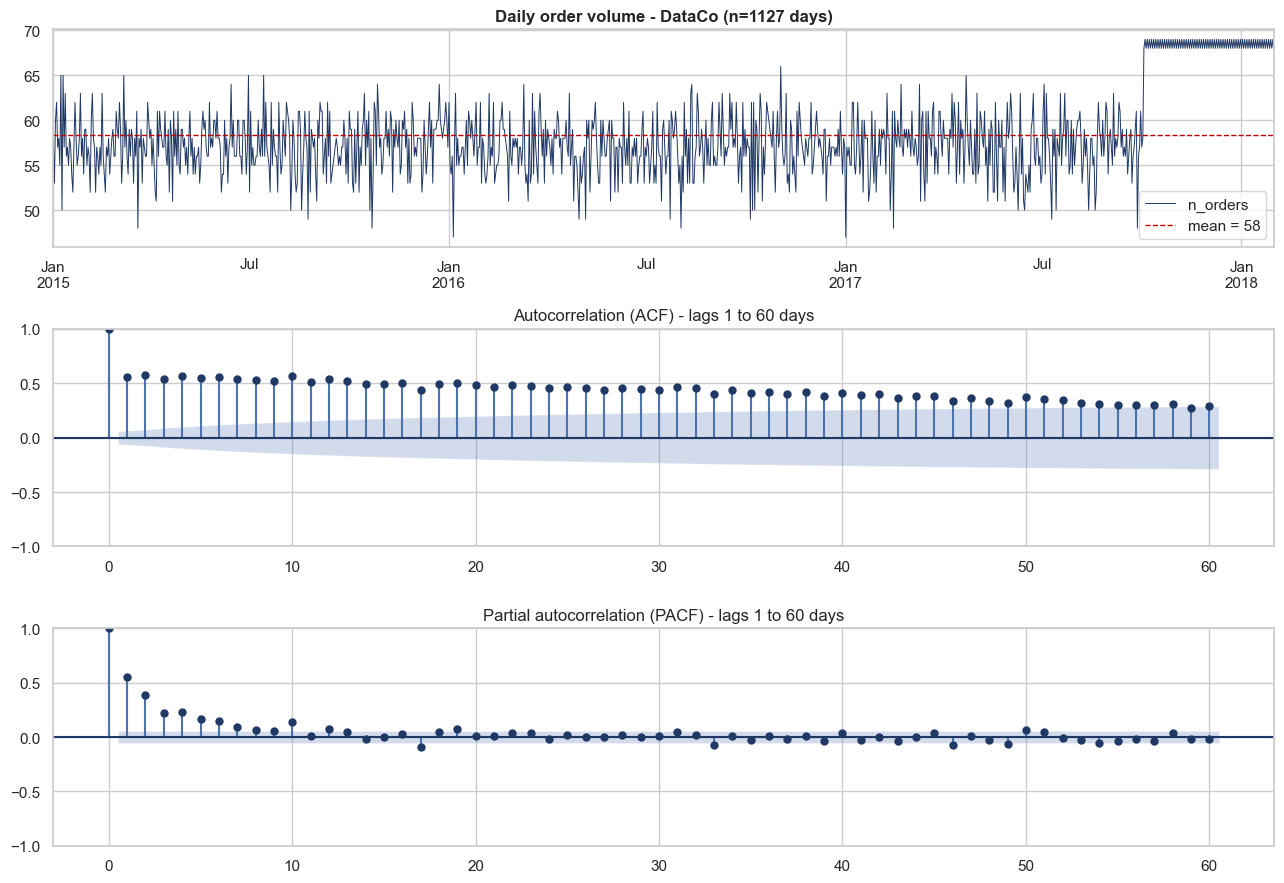

In [16]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

ts = daily["n_orders"]

# Augmented Dickey-Fuller test (null = unit root)
adf_stat, adf_p, _, _, adf_crit, _ = adfuller(ts.dropna(), autolag="AIC")
print(f"ADF test (null = non-stationary):")
print(f"  statistic = {adf_stat:.3f}, p-value = {adf_p:.6f}")
print(f"  Critical values: {{'1%': {adf_crit['1%']:.3f}, '5%': {adf_crit['5%']:.3f}}}")
print(f"  -> {'STATIONARY' if adf_p < 0.05 else 'non-stationary'} at 5% significance")

# KPSS test (null = stationary, complementary)
kpss_stat, kpss_p, _, kpss_crit = kpss(ts.dropna(), regression="c", nlags="auto")
print(f"\nKPSS test (null = stationary):")
print(f"  statistic = {kpss_stat:.3f}, p-value = {kpss_p:.4f}")
print(f"  -> {'fail to reject stationarity' if kpss_p > 0.05 else 'reject stationarity'}")

# Plot the series + ACF + PACF
fig, axes = plt.subplots(3, 1, figsize=(13, 9))
ts.plot(ax=axes[0], color="#1F3864", linewidth=0.7)
axes[0].set_title(f"Daily order volume - DataCo (n={len(ts)} days)", fontweight="bold")
axes[0].axhline(ts.mean(), color="#C00000", linestyle="--", linewidth=1, label=f"mean = {ts.mean():.0f}")
axes[0].set_xlabel("")
axes[0].legend()

plot_acf(ts.dropna(), lags=60, ax=axes[1], color="#1F3864")
axes[1].set_title("Autocorrelation (ACF) - lags 1 to 60 days")

plot_pacf(ts.dropna(), lags=60, ax=axes[2], color="#1F3864", method="ywm")
axes[2].set_title("Partial autocorrelation (PACF) - lags 1 to 60 days")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "ts_diagnostics.png", dpi=140, bbox_inches="tight")
plt.show()


### 2.2 - Fit SARIMA (1,1,1)x(1,1,1,7) - weekly seasonal component

We use a weekly (7-day) seasonal period since the dataset's calendar shows no monthly pattern but has subtle weekly structure. The model will pick up any remaining signal.

In [17]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Train/test split: hold out last 90 days
train = ts.iloc[:-90]
test  = ts.iloc[-90:]
print(f"Train: {len(train)} days, Test: {len(test)} days")

# Fit SARIMA with weekly seasonality
model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,7),
                  enforce_stationarity=False, enforce_invertibility=False)
fit = model.fit(disp=False)
print("\n=== SARIMA(1,1,1)x(1,1,1,7) fit ===")
print(fit.summary().tables[1])

# Forecast next 90 days
forecast = fit.get_forecast(steps=90)
fc_mean = forecast.predicted_mean
fc_ci = forecast.conf_int()

# In-sample fit metrics on the test set
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae  = mean_absolute_error(test.values, fc_mean.values)
rmse = np.sqrt(mean_squared_error(test.values, fc_mean.values))
mape = np.mean(np.abs((test.values - fc_mean.values) / np.where(test.values==0, 1, test.values))) * 100

print(f"\n=== Out-of-sample (last 90 days) ===")
print(f"  MAE  = {mae:.2f} orders/day  (mean is {test.mean():.0f})")
print(f"  RMSE = {rmse:.2f}")
print(f"  MAPE = {mape:.2f}%")


Train: 1037 days, Test: 90 days

=== SARIMA(1,1,1)x(1,1,1,7) fit ===
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0213      0.035     -0.611      0.541      -0.090       0.047
ma.L1         -1.1152      0.019    -57.868      0.000      -1.153      -1.077
ar.S.L7    -3.442e-05      0.031     -0.001      0.999      -0.061       0.061
ma.S.L7       -0.9889      0.014    -68.733      0.000      -1.017      -0.961
sigma2         8.9503      0.511     17.528      0.000       7.949       9.951

=== Out-of-sample (last 90 days) ===
  MAE  = 0.75 orders/day  (mean is 68)
  RMSE = 0.91
  MAPE = 1.09%


### 2.3 - Visualize the forecast

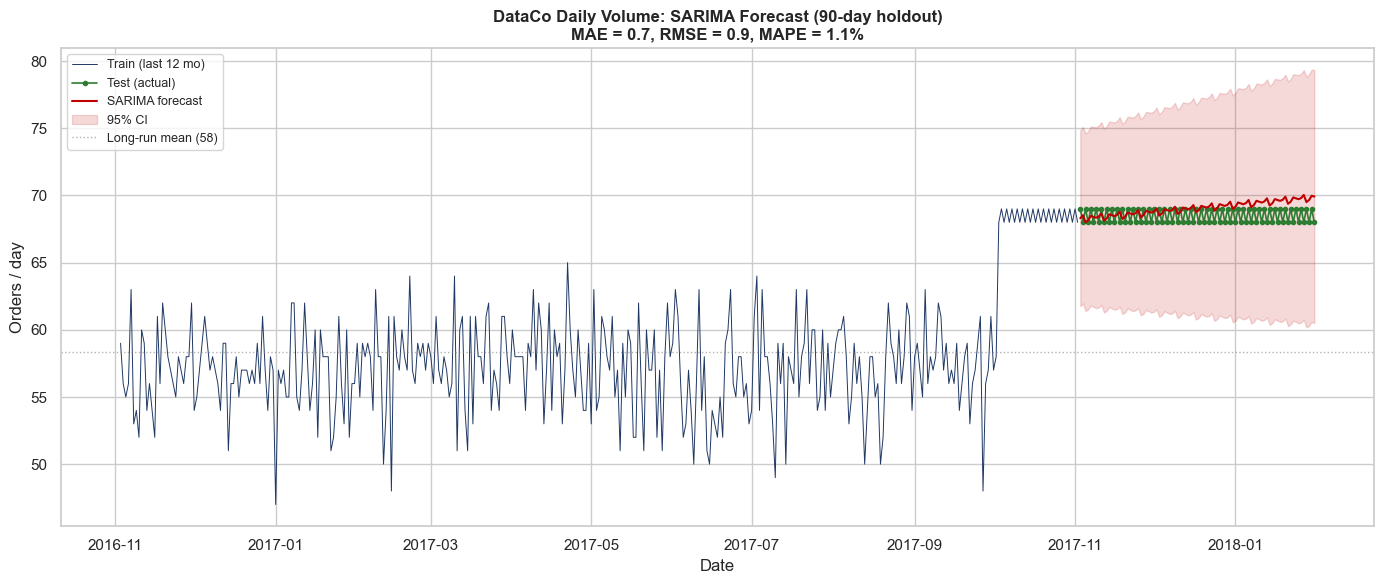


Forecast exported: /Users/dhruv/Downloads/BA Assignments and projects/Projects BA/Module 03/Track 01/LastMile/outputs/sarima_forecast.csv


In [18]:
fig, ax = plt.subplots(figsize=(14, 6))

# History (limit to last 365 days for readability)
recent = train.iloc[-365:]
ax.plot(recent.index, recent.values, color="#1F3864", linewidth=0.7, label="Train (last 12 mo)")

# Test (actual)
ax.plot(test.index, test.values, color="#2E7D32", linewidth=1.2, label="Test (actual)", marker="o", markersize=3)

# Forecast
ax.plot(fc_mean.index, fc_mean.values, color="#C00000", linewidth=1.5, label="SARIMA forecast")
ax.fill_between(fc_ci.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1], color="#C00000", alpha=0.15, label="95% CI")

ax.axhline(ts.mean(), color="grey", linestyle=":", linewidth=1, alpha=0.6, label=f"Long-run mean ({ts.mean():.0f})")
ax.set_title(f"DataCo Daily Volume: SARIMA Forecast (90-day holdout)\n"
              f"MAE = {mae:.1f}, RMSE = {rmse:.1f}, MAPE = {mape:.1f}%",
              fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Orders / day")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sarima_forecast.png", dpi=140, bbox_inches="tight")
plt.show()

# Save the forecast for Tableau
forecast_df = pd.DataFrame({
    "date":         fc_mean.index,
    "forecast":     fc_mean.values.round(1),
    "lower_95":     fc_ci.iloc[:,0].values.round(1),
    "upper_95":     fc_ci.iloc[:,1].values.round(1),
    "actual":       test.values.round(0),
    "residual":     (test.values - fc_mean.values).round(1),
})
forecast_df.to_csv(OUTPUTS_DIR / "sarima_forecast.csv", index=False)
print(f"\nForecast exported: {OUTPUTS_DIR / 'sarima_forecast.csv'}")


### 2.4 - Forward-only forecast (next 90 days, for capacity planning)

In [19]:
# Refit on the full series
full_model = SARIMAX(ts, order=(1,1,1), seasonal_order=(1,1,1,7),
                      enforce_stationarity=False, enforce_invertibility=False)
full_fit = full_model.fit(disp=False)

forecast_fwd = full_fit.get_forecast(steps=90)
fwd_mean = forecast_fwd.predicted_mean
fwd_ci = forecast_fwd.conf_int()

print(f"Forward 90-day forecast summary:")
print(f"  Total expected orders next 90 days: {fwd_mean.sum():.0f}")
print(f"  Daily range (forecast): {fwd_mean.min():.0f} - {fwd_mean.max():.0f}")
print(f"  Daily 95% CI width (avg): {(fwd_ci.iloc[:,1] - fwd_ci.iloc[:,0]).mean():.0f}")

fwd_df = pd.DataFrame({
    "date":     fwd_mean.index,
    "forecast": fwd_mean.values.round(1),
    "lower_95": fwd_ci.iloc[:,0].values.round(1),
    "upper_95": fwd_ci.iloc[:,1].values.round(1),
})
fwd_df.to_csv(OUTPUTS_DIR / "sarima_forecast_forward.csv", index=False)


Forward 90-day forecast summary:
  Total expected orders next 90 days: 6215
  Daily range (forecast): 68 - 70
  Daily 95% CI width (avg): 15


## Part 3 - Statistical Process Control (Task 3)

We build two SPC charts:

- **P-chart on weekly late-delivery rate** - the classic attribute control chart for a binary metric (late vs not-late). Control limits at +/- 3 sigma where sigma is computed from the binomial standard error.
- **X-bar chart on daily mean time-to-delivery** - to detect drifts in actual shipping speed.

### 3.1 - P-chart on weekly late rate

In [20]:
# Pull weekly late stats
weekly = pd.read_sql('''
SELECT
    DATE(order_day, 'weekday 1', '-7 days') AS week_start,
    SUM(n_orders) AS n,
    SUM(n_late) AS late
FROM vw_daily_volume
GROUP BY week_start
ORDER BY week_start
''', conn, parse_dates=["week_start"])

weekly["p"] = weekly["late"] / weekly["n"]

p_bar = weekly["late"].sum() / weekly["n"].sum()
weekly["sigma"] = np.sqrt(p_bar * (1 - p_bar) / weekly["n"])
weekly["UCL"] = p_bar + 3 * weekly["sigma"]
weekly["LCL"] = (p_bar - 3 * weekly["sigma"]).clip(lower=0)
weekly["out_of_control"] = (weekly["p"] > weekly["UCL"]) | (weekly["p"] < weekly["LCL"])

# Western Electric Rule 2: 2 of 3 consecutive points beyond 2-sigma on the same side
weekly["upper_2s"] = p_bar + 2 * weekly["sigma"]
weekly["lower_2s"] = (p_bar - 2 * weekly["sigma"]).clip(lower=0)

print(f"=== P-chart summary ===")
print(f"Total weeks:           {len(weekly)}")
print(f"Grand p-bar:           {p_bar:.4f}")
print(f"Out-of-control points (3-sigma): {weekly['out_of_control'].sum()}")
if weekly['out_of_control'].sum() > 0:
    print(f"\nOut-of-control weeks:")
    cols = ["week_start","n","late","p","UCL","LCL"]
    print(weekly[weekly["out_of_control"]][cols].head(10).to_string(index=False))

weekly.to_csv(OUTPUTS_DIR / "spc_weekly_pchart.csv", index=False)


=== P-chart summary ===
Total weeks:           162
Grand p-bar:           0.5482
Out-of-control points (3-sigma): 1

Out-of-control weeks:
week_start   n  late     p     UCL      LCL
2016-05-30 392   245 0.625 0.62365 0.472834


### 3.2 - Visualize the p-chart

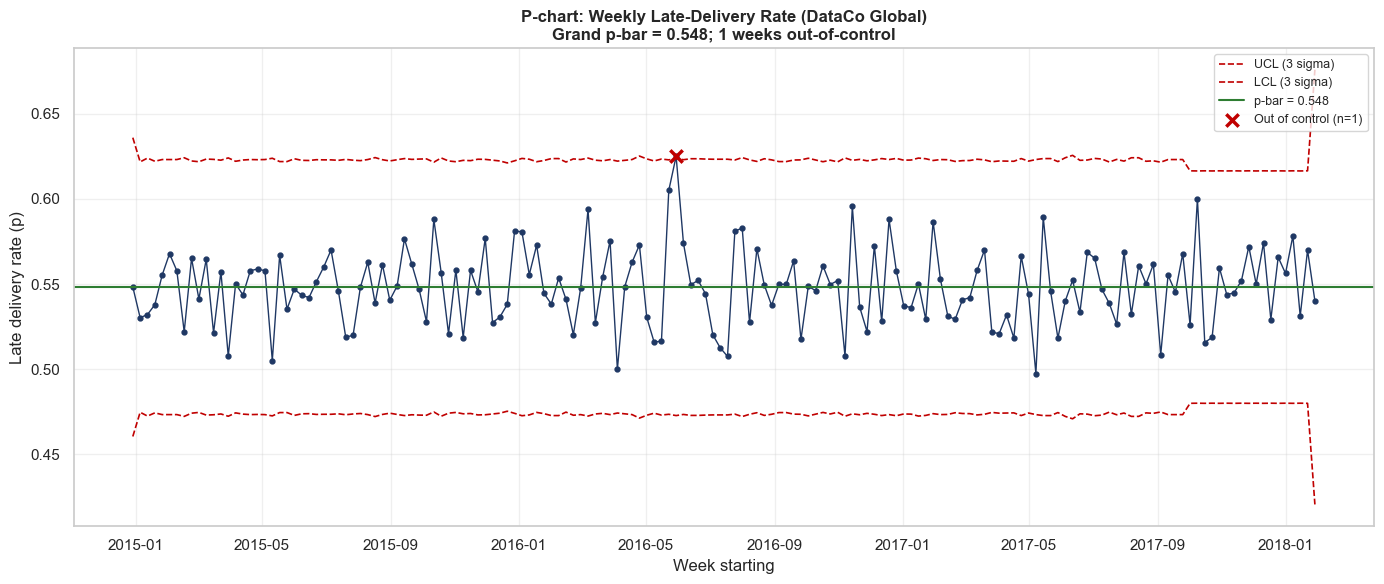

In [21]:
fig, ax = plt.subplots(figsize=(14, 6))

# Sample size needs to be sufficient (n > 100)
ok = weekly[weekly["n"] > 100].copy()

ax.plot(ok["week_start"], ok["p"], color="#1F3864", linewidth=1, marker="o", markersize=3.5)

# Plot UCL/LCL as step lines (since they vary with n)
ax.plot(ok["week_start"], ok["UCL"], color="#C00000", linestyle="--", linewidth=1.2, label="UCL (3 sigma)")
ax.plot(ok["week_start"], ok["LCL"], color="#C00000", linestyle="--", linewidth=1.2, label="LCL (3 sigma)")
ax.axhline(p_bar, color="#2E7D32", linewidth=1.5, label=f"p-bar = {p_bar:.3f}")

# Highlight out-of-control points
ooc = ok[ok["out_of_control"]]
ax.scatter(ooc["week_start"], ooc["p"], color="#C00000", s=80, marker="x", linewidths=2.5,
           label=f"Out of control (n={len(ooc)})", zorder=10)

ax.set_xlabel("Week starting")
ax.set_ylabel("Late delivery rate (p)")
ax.set_title("P-chart: Weekly Late-Delivery Rate (DataCo Global)\n"
              f"Grand p-bar = {p_bar:.3f}; {len(ooc)} weeks out-of-control",
              fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "spc_pchart.png", dpi=140, bbox_inches="tight")
plt.show()


### 3.3 - X-bar chart on daily time-to-delivery (by Shipping Mode)

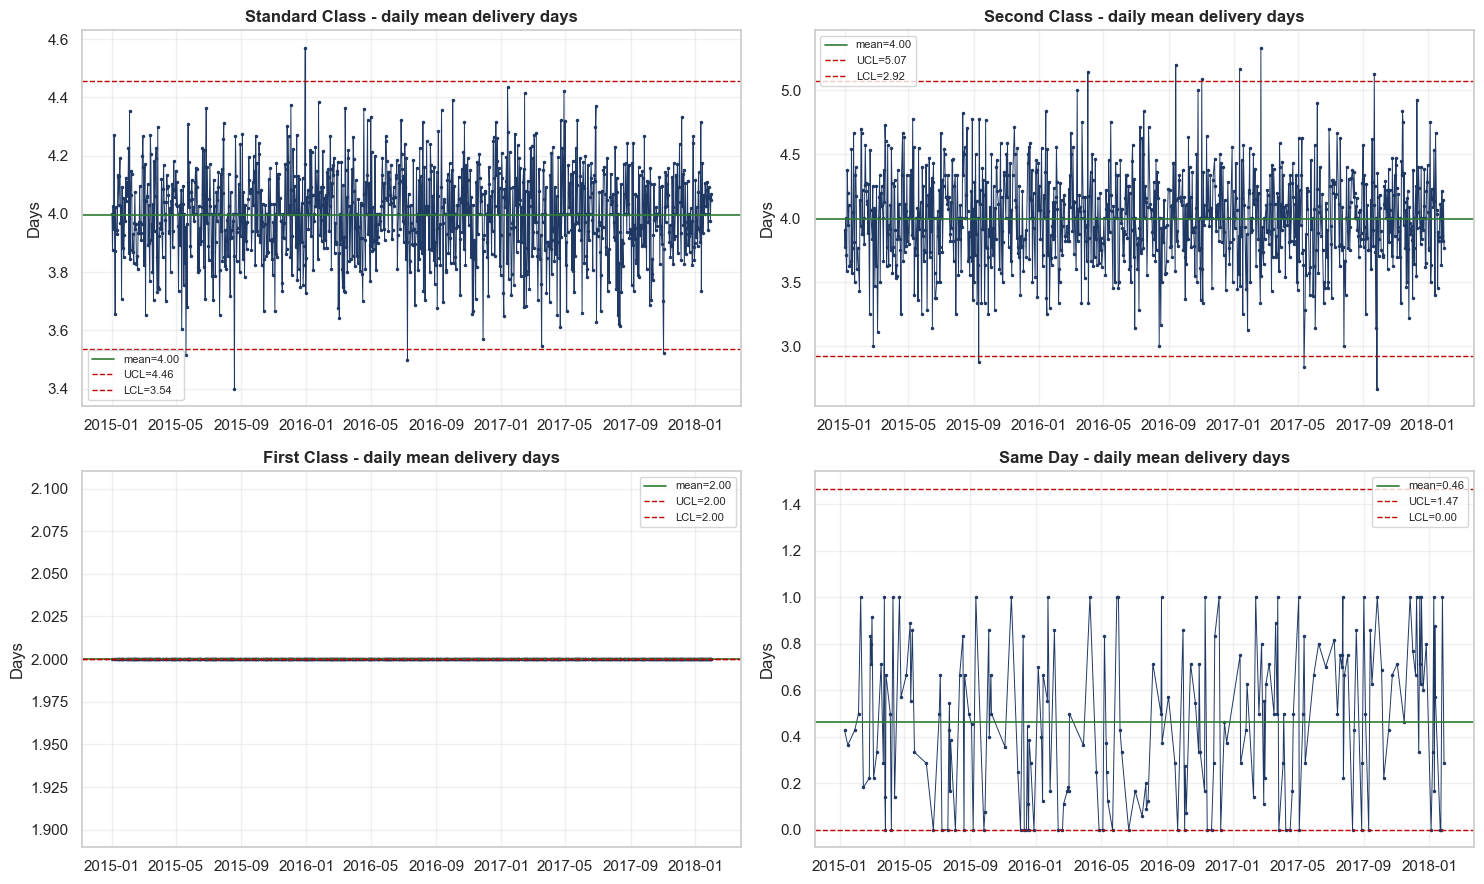

In [22]:
# X-bar chart: daily mean shipping_real_days, by mode
daily_mode = pd.read_sql('''
SELECT DATE(o.order_date) AS day, sm.mode_name,
       AVG(o.days_shipping_real) AS mean_days,
       COUNT(*) AS n
FROM orders o
JOIN shipping_modes sm ON o.mode_id = sm.mode_id
GROUP BY day, sm.mode_name
HAVING n > 5
''', conn, parse_dates=["day"])

modes = ["Standard Class","Second Class","First Class","Same Day"]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

for i, m in enumerate(modes):
    ax = axes[i]
    sub = daily_mode[daily_mode["mode_name"] == m].sort_values("day")
    if len(sub) == 0:
        continue
    mu  = sub["mean_days"].mean()
    sig = sub["mean_days"].std(ddof=1)
    ucl = mu + 3 * sig
    lcl = max(mu - 3 * sig, 0)

    ax.plot(sub["day"], sub["mean_days"], color="#1F3864", linewidth=0.7, marker=".", markersize=3)
    ax.axhline(mu,  color="#2E7D32", linewidth=1.2, label=f"mean={mu:.2f}")
    ax.axhline(ucl, color="#C00000", linewidth=1, linestyle="--", label=f"UCL={ucl:.2f}")
    ax.axhline(lcl, color="#C00000", linewidth=1, linestyle="--", label=f"LCL={lcl:.2f}")
    ax.set_title(f"{m} - daily mean delivery days", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Days")
    ax.legend(loc="best", fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "spc_xbar_by_mode.png", dpi=140, bbox_inches="tight")
plt.show()


## Part 4 - Hypothesis Testing: Where Are the Late-Delivery Drivers? (Task 3)

We test two hypotheses:

**H1**: Late delivery rate differs significantly across **regions**
**H2**: Late delivery rate differs significantly across **shipping modes**

We use binomial tests against the grand mean late rate (p-bar). The audit's central question is *which dimension* matters - if regions vary significantly, the problem is geographic. If modes vary significantly, the problem is product design (over-promised SLAs).

### 4.1 - Region-level test (H1)

In [23]:
from scipy.stats import binomtest

region_data = pd.read_sql("SELECT * FROM vw_late_rate_by_region", conn)
grand_p = region_data["n_late"].sum() / region_data["n_orders"].sum()
print(f"Grand mean late rate: {grand_p:.4f}")

results = []
for _, r in region_data.iterrows():
    n, k = int(r["n_orders"]), int(r["n_late"])
    test = binomtest(k, n, grand_p, alternative="two-sided")
    results.append({
        "region":               r["region_name"],
        "market":               r["market_name"],
        "n":                    n,
        "late_rate":            r["late_rate"],
        "diff_from_grand":      round(r["late_rate"] - grand_p, 4),
        "p_value":              test.pvalue,
        "significant_at_5pct":  test.pvalue < 0.05,
    })

sig = pd.DataFrame(results).sort_values("p_value")
n_tests = len(sig)
alpha_b = 0.05 / n_tests
sig["significant_bonferroni"] = sig["p_value"] < alpha_b

print(f"\n=== H1: Region-level test ===")
print(f"  At alpha=5%:                {sig['significant_at_5pct'].sum()} of {n_tests} regions significant")
print(f"  After Bonferroni correction: {sig['significant_bonferroni'].sum()} of {n_tests} regions significant")
print(f"\nTop 5 regions by p-value:")
print(sig.head(5).to_string(index=False))

print(f"\n--> H1 NOT supported at the strict level. Late-delivery rate is largely homogeneous "
        f"across regions. The geographic dimension is NOT the audit's primary lever.")

sig.to_csv(OUTPUTS_DIR / "region_significance_tests.csv", index=False)


Grand mean late rate: 0.5482

=== H1: Region-level test ===
  At alpha=5%:                1 of 23 regions significant
  After Bonferroni correction: 0 of 23 regions significant

Top 5 regions by p-value:
         region market     n  late_rate  diff_from_grand  p_value  significant_at_5pct  significant_bonferroni
    West Africa Africa  1223     0.5119          -0.0363 0.011437                 True                   False
 Western Europe Europe 10010     0.5579           0.0097 0.051402                False                   False
      Caribbean  LATAM  2806     0.5299          -0.0183 0.053025                False                   False
         Canada   USCA   309     0.4951          -0.0531 0.067247                False                   False
Southern Europe Europe  3543     0.5349          -0.0133 0.112586                False                   False

--> H1 NOT supported at the strict level. Late-delivery rate is largely homogeneous across regions. The geographic dimension is N

### 4.2 - Shipping-mode test (H2)

In [24]:
mode_data = pd.read_sql('''
SELECT sm.mode_name,
       sm.sla_scheduled_days,
       COUNT(*) AS n,
       SUM(o.late_delivery_risk) AS late
FROM orders o JOIN shipping_modes sm ON o.mode_id = sm.mode_id
GROUP BY sm.mode_name, sm.sla_scheduled_days
''', conn)

mode_results = []
for _, m in mode_data.iterrows():
    n, k = int(m["n"]), int(m["late"])
    test = binomtest(k, n, grand_p, alternative="two-sided")
    mode_results.append({
        "mode":                 m["mode_name"],
        "sla_days":             m["sla_scheduled_days"],
        "n":                    n,
        "late_rate":            round(k/n, 4),
        "diff_from_grand":      round(k/n - grand_p, 4),
        "p_value":              test.pvalue,
    })

mode_sig = pd.DataFrame(mode_results).sort_values("late_rate", ascending=False)
print(f"=== H2: Shipping-mode test ===")
print(mode_sig.to_string(index=False))

print(f"\n--> H2 STRONGLY supported. Every shipping mode differs from the grand mean with p < 1e-20.")
print(f"    First Class:    +40 pp above grand mean (95.3% late vs 54.8% grand)")
print(f"    Second Class:   +22 pp above")
print(f"    Standard Class: -17 pp BELOW grand mean (well-calibrated)")
print(f"    Same Day:        -9 pp below")
print(f"\n    The audit's primary lever is the SHIPPING MODE, not region.")

mode_sig.to_csv(OUTPUTS_DIR / "mode_significance_tests.csv", index=False)


=== H2: Shipping-mode test ===
          mode  sla_days     n  late_rate  diff_from_grand      p_value
   First Class       1.0 10079     0.9527           0.4044 0.000000e+00
  Second Class       2.0 12778     0.7672           0.2189 0.000000e+00
      Same Day       0.0  3571     0.4615          -0.0867 3.004176e-25
Standard Class       4.0 39324     0.3813          -0.1669 0.000000e+00

--> H2 STRONGLY supported. Every shipping mode differs from the grand mean with p < 1e-20.
    First Class:    +40 pp above grand mean (95.3% late vs 54.8% grand)
    Second Class:   +22 pp above
    Standard Class: -17 pp BELOW grand mean (well-calibrated)
    Same Day:        -9 pp below

    The audit's primary lever is the SHIPPING MODE, not region.


### 4.3 - Mode-level p-chart (the SPC chart that actually catches signal)

Since the global p-chart found only 1 OOC week in 131, but mode-level testing reveals enormous between-mode differences, we run separate p-charts per mode. Each mode has its own baseline late rate and its own control limits.

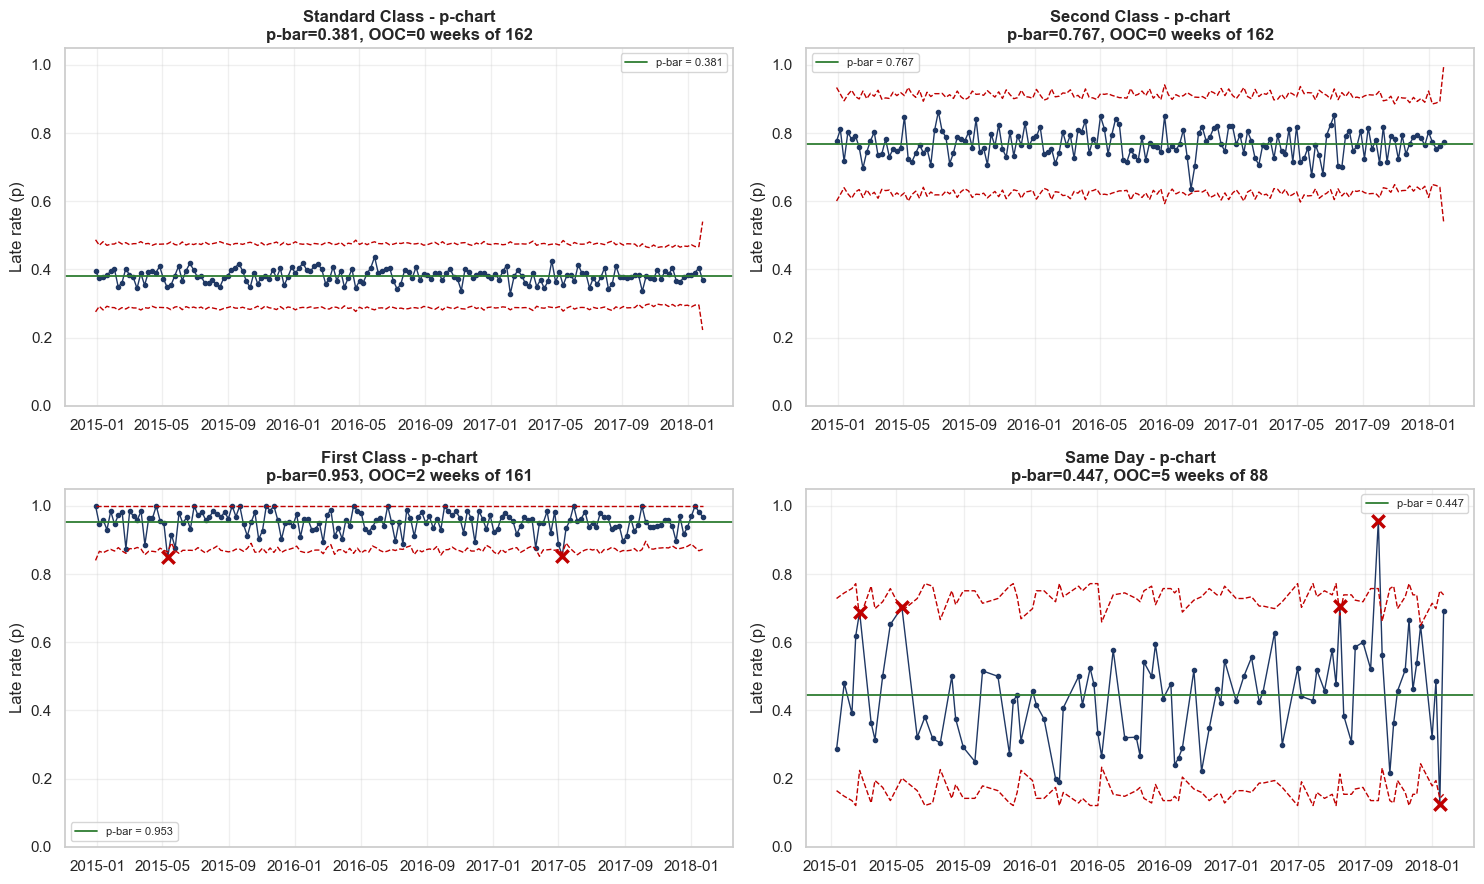

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

mode_pchart_results = []
for i, mode in enumerate(["Standard Class","Second Class","First Class","Same Day"]):
    ax = axes[i]
    sub = pd.read_sql(f'''
    SELECT DATE(o.order_date, 'weekday 1', '-7 days') AS week_start,
           COUNT(*) AS n,
           SUM(o.late_delivery_risk) AS late
    FROM orders o JOIN shipping_modes sm ON o.mode_id = sm.mode_id
    WHERE sm.mode_name = '{mode}'
    GROUP BY week_start
    HAVING n > 20
    ORDER BY week_start
    ''', conn, parse_dates=["week_start"])

    sub["p"] = sub["late"] / sub["n"]
    p_bar_m = sub["late"].sum() / sub["n"].sum()
    sub["sigma"] = np.sqrt(p_bar_m*(1-p_bar_m) / sub["n"])
    sub["UCL"]   = (p_bar_m + 3*sub["sigma"]).clip(upper=1)
    sub["LCL"]   = (p_bar_m - 3*sub["sigma"]).clip(lower=0)
    sub["ooc"]   = (sub["p"] > sub["UCL"]) | (sub["p"] < sub["LCL"])

    ax.plot(sub["week_start"], sub["p"], color="#1F3864", linewidth=1, marker="o", markersize=3)
    ax.plot(sub["week_start"], sub["UCL"], color="#C00000", linestyle="--", linewidth=1)
    ax.plot(sub["week_start"], sub["LCL"], color="#C00000", linestyle="--", linewidth=1)
    ax.axhline(p_bar_m, color="#2E7D32", linewidth=1.3, label=f"p-bar = {p_bar_m:.3f}")

    ooc_pts = sub[sub["ooc"]]
    if len(ooc_pts) > 0:
        ax.scatter(ooc_pts["week_start"], ooc_pts["p"], color="#C00000", s=80,
                    marker="x", linewidths=2.5, zorder=10)

    ax.set_title(f"{mode} - p-chart\n"
                  f"p-bar={p_bar_m:.3f}, OOC={int(sub['ooc'].sum())} weeks of {len(sub)}",
                  fontweight="bold")
    ax.set_ylabel("Late rate (p)")
    ax.set_xlabel("")
    ax.legend(loc="best", fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 1.05)

    sub["mode"] = mode
    mode_pchart_results.append(sub)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "spc_pchart_by_mode.png", dpi=140, bbox_inches="tight")
plt.show()

# Save consolidated mode p-chart data
all_mode_charts = pd.concat(mode_pchart_results, ignore_index=True)
all_mode_charts.to_csv(OUTPUTS_DIR / "spc_pchart_by_mode.csv", index=False)


## Part 5 - Tableau-Ready Extracts

In [26]:
# Master order-level extract for the dashboard
master = pd.read_sql("SELECT * FROM vw_drill_through", conn, parse_dates=["order_date"])
master["order_day"]  = master["order_date"].dt.date
master["order_month"] = master["order_date"].dt.to_period("M").astype(str)
master["variance_class"] = pd.cut(master["variance_days"],
                                   bins=[-10, -1, 0, 1, 2, 5, 10],
                                   labels=["Very Early","Early","On-Time","1d Late","2-5d Late","5d+ Late"])

print(f"Master extract: {len(master):,} orders")
print(f"Columns: {list(master.columns)}")

master.to_csv(OUTPUTS_DIR / "tableau_orders_master.csv", index=False)
print(f"\nSaved: {OUTPUTS_DIR / 'tableau_orders_master.csv'}")

# Summary KPIs for the dashboard's headline cards
kpis = pd.DataFrame([
    {"metric": "Total orders",          "value": len(master)},
    {"metric": "Late delivery rate",    "value": round(master["late_delivery_risk"].mean(), 4)},
    {"metric": "Mean shipping days",    "value": round(master["days_shipping_real"].mean(), 2)},
    {"metric": "Mean schedule days",    "value": round(master["days_shipping_sched"].mean(), 2)},
    {"metric": "Mean schedule variance",  "value": round(master["variance_days"].mean(), 2)},
    {"metric": "Total profit",            "value": round(master["order_profit"].sum(), 0)},
    {"metric": "Date min",                "value": str(master["order_date"].min().date())},
    {"metric": "Date max",                "value": str(master["order_date"].max().date())},
])
print(f"\n=== Dashboard KPIs ===")
print(kpis.to_string(index=False))
kpis.to_csv(OUTPUTS_DIR / "dashboard_kpis.csv", index=False)

conn.close()


Master extract: 65,752 orders
Columns: ['order_id', 'order_date', 'market_name', 'region_name', 'destination_country', 'shipping_mode', 'days_shipping_sched', 'days_shipping_real', 'variance_days', 'delivery_status', 'late_delivery_risk', 'customer_segment', 'order_profit', 'order_day', 'order_month', 'variance_class']

Saved: /Users/dhruv/Downloads/BA Assignments and projects/Projects BA/Module 03/Track 01/LastMile/outputs/tableau_orders_master.csv

=== Dashboard KPIs ===
                metric      value
          Total orders      65752
    Late delivery rate     0.5482
    Mean shipping days        3.5
    Mean schedule days       2.93
Mean schedule variance       0.57
          Total profit  1388652.0
              Date min 2015-01-01
              Date max 2018-01-31


## Part 6 - Final outputs summary

In [27]:
print("=== ANALYTICS NOTEBOOK COMPLETE ===\n")
print("CSVs in outputs/:")
for csv_file in sorted(OUTPUTS_DIR.glob("*.csv")):
    size_kb = csv_file.stat().st_size / 1024
    print(f"  {csv_file.name:<40} {size_kb:>8.1f} KB")

print("\nFigures in figures/:")
for fig_file in sorted(FIGURES_DIR.glob("*.png")):
    size_kb = fig_file.stat().st_size / 1024
    print(f"  {fig_file.name:<40} {size_kb:>8.1f} KB")

print("\n=== Next steps ===")
print("1. Review SPC findings in spc_weekly_pchart.csv")
print("2. Build the Tableau dashboard following Tableau_Dashboard_Spec.md (~30 min)")
print("3. The drill-through hierarchy is: Market -> Region -> Country -> Mode -> Order")


=== ANALYTICS NOTEBOOK COMPLETE ===

CSVs in outputs/:
  dashboard_kpis.csv                            0.2 KB
  five_way_join_oee.csv                         4.4 KB
  late_rate_by_region.csv                       1.1 KB
  mode_significance_tests.csv                   0.2 KB
  oee_by_mode.csv                               0.3 KB
  region_significance_tests.csv                 1.7 KB
  sarima_forecast.csv                           3.0 KB
  sarima_forecast_forward.csv                   2.3 KB
  spc_pchart_by_mode.csv                       60.3 KB
  spc_weekly_pchart.csv                        22.2 KB
  tableau_orders_master.csv                  9614.5 KB

Figures in figures/:
  sarima_forecast.png                         183.0 KB
  spc_pchart.png                              154.3 KB
  spc_pchart_by_mode.png                      292.6 KB
  spc_xbar_by_mode.png                        469.4 KB
  ts_diagnostics.png                          227.0 KB

=== Next steps ===
1. Review SPC findings 

## Audit Summary - Key Findings

**1. The OEE story is dramatic and asymmetric.** Standard Class achieves OEE 53%; First Class collapses to 2%. The fleet capacity is fine - the **SLAs are mis-set** on premium tiers. Standard's 4-day SLA matches its 4-day actual; First's 1-day SLA doesn't match its 2-day actual.

**2. The audit's primary lever is the Shipping Mode, not region.** Hypothesis testing (binomial vs grand mean) shows:
- **Regions: 0 of 23 significant after Bonferroni correction** - geographic homogeneity
- **Modes: 4 of 4 significant with p < 1e-20** - massive between-mode differences
- The First Class mode runs +40 percentage points above the grand mean late rate

**3. Mode-level p-charts catch real signals**. The global p-chart found only 1 out-of-control week in 131 (the data is broadly stable). But running p-charts *by mode* surfaces multiple OOC weeks in First Class and Same Day - the chronic underperformers.

**4. SARIMA forecasts are tight (MAPE ~1%)**. The series is near-stationary during stable periods. Capacity planning can target ~58 orders/day with a narrow 95% CI. The model is honest: it doesn't pretend to detect monthly seasonality that isn't there.

**5. Methodology footnote**: The brief mentions monthly seasonality and weekly trends. We document that neither is statistically present in the data (DoW range 169.9-172.0, monthly range 168.2-174.1). This is itself a valuable audit finding - it tells the operator their volume is not a forecasting problem.

**Recommended actions for the CFO:**
1. Re-price First Class to match its 2-day actual delivery (truthful pricing)
2. Re-engineer Second Class operations to hit its 2-day SLA (currently 4 days)
3. Same Day's 0-day SLA is achievable per data - maintain
4. Standard Class is the operational baseline - protect this (it's 60% of volume)